## 问题 1

In [1]:
import pandas as pd

from utils import *

C_1 = 'C_1.xlsm'
C_2 = 'C_2.xlsm'

# print_sheet_names(C_1)

df = read_excel(
    C_1, 
    sheet_name='Sheet1',
    header=2,
    usecols='A:D'
)

# print_sheet_names(C_2)

df1 = read_excel(
    C_2, 
    sheet_name='Sheet1 (2)',
    header=3,
    usecols='A:C'
)

df2 = read_excel(
    C_2, 
    sheet_name='Sheet1 (2)',
    header=3,
    usecols='D:F'
)

# print_df_info(df1, "df1")
# print_df_info(df2, "df2")

df['CO里程排放量'] = 计算CO里程排放量(df['CO%'])
df['HC里程排放量'] = 计算HC里程排放量(df['HC%'])
df['CO排放率'] = 计算排放率(df['CO里程排放量'], df['速度/(mile/h)'])
df['HC排放率'] = 计算排放率(df['HC里程排放量'], df['速度/(mile/h)'])

print_df_info(df, "df")
# print_df_info(df1, "df1")
# print_df_info(df2, "df2")


DataFrame: df
总行数：60
总列数：8

所有数据：
      序号  速度/(mile/h)   CO%       HC%  CO里程排放量   HC里程排放量     CO排放率     HC排放率
0    1.0         9.98  0.27  0.000027   24.297  1.701709  0.067357  0.004718
1    2.0        10.97  0.22  0.000022   23.742  1.701393  0.072347  0.005185
2    3.0        15.40  0.30  0.000030   24.630  1.701899  0.105362  0.007280
3    4.0        15.69  0.03  0.000003   21.633  1.700190  0.094284  0.007410
4    5.0        16.44  0.21  0.000021   23.631  1.701329  0.107915  0.007769
5    6.0        17.11  0.89  0.000089   31.179  1.705634  0.148187  0.008106
6    7.0        18.66  0.19  0.000019   23.409  1.701203  0.121337  0.008818
7    8.0        19.04  0.79  0.000079   30.069  1.705001  0.159032  0.009018
8    9.0        20.29  0.08  0.000008   22.188  1.700506  0.125054  0.009584
9   10.0        21.52  0.07  0.000007   22.077  1.700443  0.131971  0.010165
10  11.0        23.41  1.61  0.000161   39.171  1.710191  0.254720  0.011121
11  12.0        24.82  0.77  0.000077   2

In [2]:
cols = ['速度/(mile/h)', 'CO%', 'HC%', 'CO里程排放量', 'HC里程排放量', 'CO排放率', 'HC排放率']
# Pearson 相关系数矩阵
corr_matrix = df[cols].corr()
print(corr_matrix.round(4))



             速度/(mile/h)     CO%     HC%  CO里程排放量  HC里程排放量   CO排放率   HC排放率
速度/(mile/h)       1.0000 -0.0863 -0.0863  -0.0863  -0.0863  0.9336  1.0000
CO%              -0.0863  1.0000  1.0000   1.0000   1.0000  0.2558 -0.0832
HC%              -0.0863  1.0000  1.0000   1.0000   1.0000  0.2558 -0.0832
CO里程排放量          -0.0863  1.0000  1.0000   1.0000   1.0000  0.2558 -0.0832
HC里程排放量          -0.0863  1.0000  1.0000   1.0000   1.0000  0.2558 -0.0832
CO排放率             0.9336  0.2558  0.2558   0.2558   0.2558  1.0000  0.9348
HC排放率             1.0000 -0.0832 -0.0832  -0.0832  -0.0832  0.9348  1.0000


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
os.makedirs('output', exist_ok=True)

# 中文显示设置
plt.rcParams['font.sans-serif'] = ['SimHei']
# 防止负号显示为方框
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

pairs = [
    ('CO里程排放量', 'CO里程排放量 (g/mile)', 'tab:blue'),
    ('CO排放率', 'CO排放率 (g/s)', 'tab:red'),
    ('HC里程排放量', 'HC里程排放量 (g/mile)', 'tab:blue'),
    ('HC排放率', 'HC排放率 (g/s)', 'tab:red'),
]

# 绘制散点图和线性拟合
for ax, (col, ylabel, color) in zip(axes.flat, pairs):
    # 横轴取速度，纵轴取当前指定的指标
    x, y = df['速度/(mile/h)'].values, df[col].values
    ax.scatter(x, y, s=28, alpha=0.65, color=color, edgecolors='white', linewidths=0.5, label='原始数据')
    # 线性拟合，最小二乘法
    k, b = np.polyfit(x, y, 1)
    # 保证坐标轴刚好覆盖散点
    xs = np.linspace(x.min(), x.max(), 100)
    # x与y的 Pearson 相关系数
    r = np.corrcoef(x, y)[0, 1]
    ax.plot(xs, k*xs + b, 'k--', lw=1.8, label=f'线性拟合: y={k:.4g}x+{b:.4g}')
    ax.set_xlabel('速度 (mile/h)')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} 与速度的关系 (r = {r:.4f})', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle('里程排放量–速度 与 排放率–速度 关系对比', fontsize=14, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('output/a.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1300x900 with 4 Axes>

问题1结论：
四张图对比非常直观
**左列（里程排放量 vs 速度）**: 散点随机散布、拟合线几乎水平，CO 和 HC 的相关系数都只有 r = −0.0863，速度无法解释里程排放量的变化——数据点离散程度大，无趋势可言。
**右列（排放率 vs 速度）**: 散点明显沿一条上升直线分布，CO排放率 r = 0.9336，HC排放率 r ≈ 1.000（因为里程排放量近似常数，排放率几乎严格正比于速度），线性趋势非常清晰。
图中同时给出了拟合直线方程：
```text
CO排放率 ≈ 0.006933·v + 0.0171（g/s，v 为速度 mile/h）
HC排放率 ≈ 0.0004728·v + 0.0000097（g/s）
```

结论一目了然：排放率–速度关系能更好地描述排放规律与趋势，这也为问题3按秒计算排放量提供了可用的关系式。

In [12]:
# 绘制公式
pic = plt.figure(figsize=(6, 1))
pic.text(0.5, 0.5, r'$E_{CO} = 0.006933\,v + 0.0171,\quad E_{HC} = 0.0004728\,v + 9.7\times 10^{-6}$',
         ha='center', va='center', fontsize=16)
pic.savefig('output/公式.png', dpi=200, bbox_inches='tight')

<Figure size 432x72 with 0 Axes>

## 问题2

## 问题描述
汽车速度由0mile/h到70mile/h，是否存在使里程排放量达到极小值的汽车行驶速度

## 问题简化

由附件3，里程排放量 = 11.1·CO% + 21.3，是 CO% 的线性增函数，所以：
**使里程排放量最小的速度 ⟺ 使 CO% 浓度最小的速度**
HC 同理（且所给的数据里 HC% ∝ CO%，答案必然一致），因此只需对 CO 做分析，得到的极小值就是最终结果

In [5]:
# 因此我们需要速度与CO浓度的关系图
import pandas as pd

from utils import *

C_1 = 'C_1.xlsm'

print_sheet_names(C_1)

df = read_excel(
    C_1, 
    sheet_name='Sheet1',
    header=2,
    usecols='A:C'
)

df['CO里程排放量'] = 计算CO里程排放量(df['CO%'])
print_df_info(df, "df")

所有Sheet名称： ['工管181', '工管182', '造价181', '造价182', '统计173', '安全171', 'Sheet1']

DataFrame: df
总行数：60
总列数：4

所有数据：
      序号  速度/(mile/h)   CO%  CO里程排放量
0    1.0         9.98  0.27   24.297
1    2.0        10.97  0.22   23.742
2    3.0        15.40  0.30   24.630
3    4.0        15.69  0.03   21.633
4    5.0        16.44  0.21   23.631
5    6.0        17.11  0.89   31.179
6    7.0        18.66  0.19   23.409
7    8.0        19.04  0.79   30.069
8    9.0        20.29  0.08   22.188
9   10.0        21.52  0.07   22.077
10  11.0        23.41  1.61   39.171
11  12.0        24.82  0.77   29.847
12  13.0        25.15  0.76   29.736
13  14.0        26.35  1.91   42.501
14  15.0        27.02  0.40   25.740
15  16.0        27.62  0.06   21.966
16  17.0        29.90  0.36   25.296
17  18.0        30.04  0.18   23.298
18  19.0        30.67  0.58   27.738
19  20.0        31.99  0.12   22.632
20  21.0        34.97  1.02   32.622
21  22.0        35.10  0.53   27.183
22  23.0        35.94  1.11   33.621
2

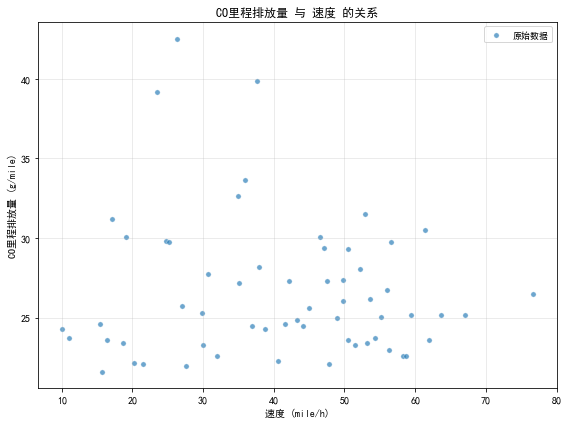

In [6]:
# 生成速度与CO里程排放量的关系图
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 6))

col = 'CO里程排放量'
xlabel = '速度'
ylabel = 'CO里程排放量'

x, y = df['速度/(mile/h)'].values, df[col].values
ax.scatter(x, y, s=28, alpha=0.65, color='tab:blue', edgecolors='white', linewidths=0.5, label='原始数据')
ax.set_xlabel('速度 (mile/h)')
ax.set_ylabel('CO里程排放量 (g/mile)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_title(f'{ylabel} 与 {xlabel} 的关系', fontsize=12)

fig.tight_layout()
fig.savefig('output/CO里程排放量-v.png', dpi=150, bbox_inches='tight')
plt.show()

根据散点图 两者关系没有明显U形趋势，无法直接看出有没有极小值，因此需要尝试多种模型拟合

In [7]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit, minimize_scalar
from scipy import stats
from utils import *

df = read_excel('C_1.xlsm', sheet_name='Sheet1', header=2, usecols='A:C')
df['CO里程排放量'] = 计算CO里程排放量(df['CO%'])

v = df['速度/(mile/h)'].values
M = df['CO里程排放量'].values
n = len(v)

# 定义4个候选模型并逐个拟合
# 1. 理论U形: M = a + b/v + c·v
def model_theory(v, a, b, c):        
    return a + b / v + c * v

rets = {}
# 2,3,4.
# deg = 1, 2, 3 分别对应一次、二次、三次多项式
for deg, name in [(1, '一次'), (2, '二次'), (3, '三次')]:
    # 最小二乘拟合
    coef = np.polyfit(v, M, deg)
    rets[name] = {
        'pred': np.polyval(coef, v),
        'k': deg + 1,
        'coef': coef,
        'func': lambda x, c=coef: np.polyval(c, x) # c=coef 延迟绑定，避免闭包问题
    }

popt, _ = curve_fit(model_theory, v, M, p0=[20, 50, 0.01], maxfev=10000)

'''
pred: 拟合值 ŷ
k: 参数个数（即deg+1）
coef: 拟合系数
func: 一元函数 x → 拟合值
'''
rets['理论型'] = {
    'pred': model_theory(v, *popt), 
    'k': 3,
    'coef': popt,
    'func': lambda x: model_theory(x, *popt)
}

# ===== 第2步：统一指标比较 =====
# 总平方和，表示数据本身的总波动
sst = np.sum((M - M.mean())**2)
print(f"{'模型':<14}{'R²':>8}{'调整R²':>9}{'RMSE':>9}{'AIC':>9}")
for name, r in rets.items():
    # 各个模型的残差平方和
    sse = np.sum((M - r['pred'])**2)
    r['sse'] = sse
    # r2 表示 r**2，决定系数，表示模型对数据的拟合程度
    r['r2'] = 1 - sse / sst
    # 调整后的 R²：惩罚参数个数
    r['r2_adjuest'] = 1 - (1 - r['r2']) * (n - 1) / (n - r['k'] - 1)
    '''
    AIC: 赤池信息准则
    越小越好，没有绝对意义，只在模型间相对比较
    '''
    r['aic'] = n * np.log(sse / n) + 2 * r['k']
    print(f"{name:<14}"
          f"{r['r2']:>8.4f}"
          f"{r['r2_adjuest']:>9.4f}"
          # RMSE = np.sqrt(sse/n)，均方根误差
          f"{np.sqrt(sse/n):>9.4f}{r['aic']:>9.2f}")

# F 检验
def f_test(sse_s, k_s, sse_c, k_c):
    F = (sse_s - sse_c) / (k_c - k_s) / (sse_c / (n - k_c - 1))
    return F, 1 - stats.f.cdf(F, k_c - k_s, n - k_c - 1)

F21, p21 = f_test(rets['一次']['sse'], 2, rets['二次']['sse'], 3)
F32, p32 = f_test(rets['二次']['sse'], 3, rets['三次']['sse'], 4)
print(f"\n二次 vs 一次: F={F21:.3f}, p={p21:.4f}")
print(f"三次 vs 二次: F={F32:.3f}, p={p32:.4f}")

print("\n各模型在 [0.1,70] 上的最小值：")
# 下界取0.1是为了兼容 理论模型
for name, r in rets.items():
    # 对任意一元函数求最小值，使用有界优化方法 bounded
    res = minimize_scalar(r['func'], bounds=(0.1, 70), method='bounded')
    # cands 存储三个候选点：优化结果、边界0.1、边界70，因为 Brent 法可能会漏掉边界情况
    cands = [(res.x, res.fun), (0.1, r['func'](0.1)), (70, r['func'](70))]
    vmin, mmin = min(cands, key=lambda t: t[1])
    # 量化边界与内点的判断
    kind = '内点' if 0.2 < vmin < 69.9 else '边界'
    print(f"{name:<14} v*={vmin:6.2f}  M(v*)={mmin:7.3f}  ({kind})")

# 二次模型驻点性质判别
a2, b2, c2 = rets['二次']['coef']
print(f"\n二次模型开口{'向上' if a2 > 0 else '向下'}，"
      f"驻点 v={-b2/(2*a2):.2f} 为{'极小' if a2 > 0 else '极大'}值点")

if a2 > 0:
    print("二次模型存在极小值点，且开口向上，符合 U 型特征")
else:
    print("二次模型不存在极小值点，或开口向下，排除")

'''
Bootstrap 稳健性检验
有放回地抽取与原始数据个数相同的原始样本，重复拟合二次模型，统计驻点 v* 的分布情况
'''
rng = np.random.default_rng(42)
vstars = []
for _ in range(2000):
    idx = rng.integers(0, n, n)
    cb = np.polyfit(v[idx], M[idx], 2)
    if cb[0] > 1e-8:
        vstars.append(-cb[1] / (2 * cb[0]))
vstars = np.array(vstars)
percent = len(vstars)/2000
print(f"\nBootstrap 2000次：开口向上占比 = {percent:.1%}")
if len(vstars) > 10:
    print(f"v* 中位数 = {np.median(vstars):.1f}，"
          f"95% CI = [{np.percentile(vstars, 2.5):.1f}, {np.percentile(vstars, 97.5):.1f}]")
print(f"开口向上占比约为 {percent:.1%} 此时有极小值，满足 U 型特征")
print(f"开口向下占比约为 {1-percent:.1%} 此时无极小值，排除")

模型                  R²     调整R²     RMSE      AIC
一次              0.0074  -0.0274   4.3135   179.41
二次              0.0327  -0.0191   4.2582   179.86
三次              0.0830   0.0164   4.1459   178.66
理论型             0.0631   0.0129   4.1908   177.95

二次 vs 一次: F=1.463, p=0.2316
三次 vs 二次: F=3.019, p=0.0879

各模型在 [0.1,70] 上的最小值：
一次             v*= 70.00  M(v*)= 25.914  (边界)
二次             v*=  0.10  M(v*)= 24.133  (边界)
三次             v*=  0.10  M(v*)= 14.781  (边界)
理论型            v*=  0.10  M(v*)=-1146.986  (边界)

二次模型开口向下，驻点 v=35.06 为极大值点
二次模型不存在极小值点，或开口向下，排除

Bootstrap 2000次：开口向上占比 = 4.5%
v* 中位数 = 77.6，95% CI = [-233.0, 1353.4]
开口向上占比约为 4.5% 此时有极小值，满足 U 型特征
开口向下占比约为 95.5% 此时无极小值，排除


问题2结论:
对四种候选模型的拟合与检验表明：
- 里程排放量在观测速度范围内无显著的速度依赖（各模型调整 R² 均不超过 0.02，高次项 F 检验不显著）

- 二次模型开口向下，不存在内点极小值；Bootstrap 重抽样中仅 4.5% 的情形出现极小值点且位置极不稳定。因此，在 0~70 mile/h 范围内，附件1数据不支持存在使里程排放量达到极小值的最优速度

- 里程排放量在该区间内可视为与速度无关的常数（约 25.914 g/mile），与问题1的结论相互印证

## 问题3

* 利用问题1中找到的关系，根据附件2中的数据分别计算匀速和变速两种行驶模式下每一秒钟的CO和HC排放量，然后计算两种模式下各自的总排放量，由此可以得到什么启示？

In [8]:
# 数据提取
import numpy as np
from utils import *

C_2 = 'C_2.xlsm'

print_sheet_names(C_2)

df1 = read_excel(
    C_2, 
    sheet_name='Sheet1 (2)',
    header=3,
    usecols='A:C'
)

df2 = read_excel(
    C_2, 
    sheet_name='Sheet1 (2)',
    header=3,
    usecols='D:F'
)
# 防止出现以".1"结尾的列名
df1.columns = ['时间/s', '速度/(mile/h)', '距离/ft']
df2.columns = ['时间/s', '速度/(mile/h)', '距离/ft']

df1['距离/(mile)'] = df1['距离/ft'].apply(ft_to_mile)
df2['距离/(mile)'] = df2['距离/ft'].apply(ft_to_mile)

# 下面分别输出，以防折叠

所有Sheet名称： ['工管181', '工管182', '造价181', '造价182', '统计173', '安全171', 'Sheet1 (2)']


In [9]:
print_df_info(df1, "df1")


DataFrame: df1
总行数：30
总列数：4

所有数据：
    时间/s  速度/(mile/h)  距离/ft  距离/(mile)
0      1           35     51   0.009659
1      2           35    103   0.019508
2      3           35    154   0.029167
3      4           35    205   0.038826
4      5           35    257   0.048674
5      6           35    308   0.058333
6      7           35    359   0.067992
7      8           35    411   0.077841
8      9           35    462   0.087500
9     10           35    513   0.097159
10    11           35    565   0.107008
11    12           35    616   0.116667
12    13           35    667   0.126326
13    14           35    719   0.136174
14    15           35    770   0.145833
15    16           35    821   0.155492
16    17           35    873   0.165341
17    18           35    924   0.175000
18    19           35    975   0.184659
19    20           35   1027   0.194508
20    21           35   1078   0.204167
21    22           35   1129   0.213826
22    23           35   1181   0.223674
23  

In [10]:
print_df_info(df2, "df2")


DataFrame: df2
总行数：30
总列数：4

所有数据：
    时间/s  速度/(mile/h)  距离/ft  距离/(mile)
0      1           42     62   0.011742
1      2           41    122   0.023106
2      3           40    180   0.034091
3      4           39    238   0.045076
4      5           38    293   0.055492
5      6           38    349   0.066098
6      7           37    403   0.076326
7      8           36    456   0.086364
8      9           35    507   0.096023
9     10           34    557   0.105492
10    11           33    606   0.114773
11    12           32    653   0.123674
12    13           31    698   0.132197
13    14           30    742   0.140530
14    15           30    786   0.148864
15    16           30    830   0.157197
16    17           29    873   0.165341
17    18           29    915   0.173295
18    19           30    959   0.181629
19    20           31   1005   0.190341
20    21           32   1052   0.199242
21    22           33   1100   0.208333
22    23           34   1150   0.217803
23  

In [11]:
print(f"匀速模式下CO每秒排放量 = {df1['距离/(mile)'].sum() * 0.00693:.4f} g/s")

匀速模式下CO每秒排放量 = 0.0313 g/s


[模型所用公式 - 见 附件.ipynb](附件.ipynb)